In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("🏥 Iniciando a Análise do Exercício 3 (Atendimento UPA)...\n")

# 1. CARREGANDO E LIMPANDO OS DADOS
nome_arquivo = '[FM2S]Lista_Exercícios_1.xlsx'
aba = '03.Atendimento_UPA'

# O parâmetro 'usecols' garante que vamos ignorar aquelas colunas Unnamed com lixo do Excel
df = pd.read_excel(nome_arquivo, sheet_name=aba, usecols=['Dia', 'Atendimento', 'Classificação de Risco', 'Tempo de Atendimento'])

print("--- Resumo dos Dados ---")
print(f"Total de atendimentos analisados: {len(df)}")
print(df['Classificação de Risco'].value_counts())
print("-" * 50)

# ====================================================================
# TRATAMENTO PARA LETRA A e B: Desempenho por Dia
# ====================================================================
# Precisamos contar quantos atendimentos no total e quantos atrasaram ("Não conforme") por dia.
# Agrupando pelo 'Dia' e contando o total de ocorrências em 'Tempo de Atendimento'
total_por_dia = df.groupby('Dia')['Tempo de Atendimento'].count().reset_index(name='Total_Atendimentos')

# Filtrando só quem atrasou e contando por dia
atrasos = df[df['Tempo de Atendimento'] == 'Não conforme']
atrasos_por_dia = atrasos.groupby('Dia')['Tempo de Atendimento'].count().reset_index(name='Atendimentos_Atrasados')

# Juntando as tabelas e calculando a Porcentagem de Atraso
desempenho_dia = pd.merge(total_por_dia, atrasos_por_dia, on='Dia', how='left')
desempenho_dia['Atendimentos_Atrasados'] = desempenho_dia['Atendimentos_Atrasados'].fillna(0) # Troca NaN por 0
desempenho_dia['%_Atraso'] = (desempenho_dia['Atendimentos_Atrasados'] / desempenho_dia['Total_Atendimentos']) * 100

media_atraso_geral = desempenho_dia['%_Atraso'].mean()

🏥 Iniciando a Análise do Exercício 3 (Atendimento UPA)...

--- Resumo dos Dados ---
Total de atendimentos analisados: 2682
Classificação de Risco
Não Urgente    1957
Urgente         618
Emergente       107
Name: count, dtype: int64
--------------------------------------------------


Gerando o Dashboard de Análise de Fila... (Feche a janela para encerrar)


C:\Users\embras\AppData\Local\Temp\ipykernel_7300\1949811754.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=atrasos, x='Classificação de Risco', order=ordem_risco, palette='Set2', ax=axes[1])


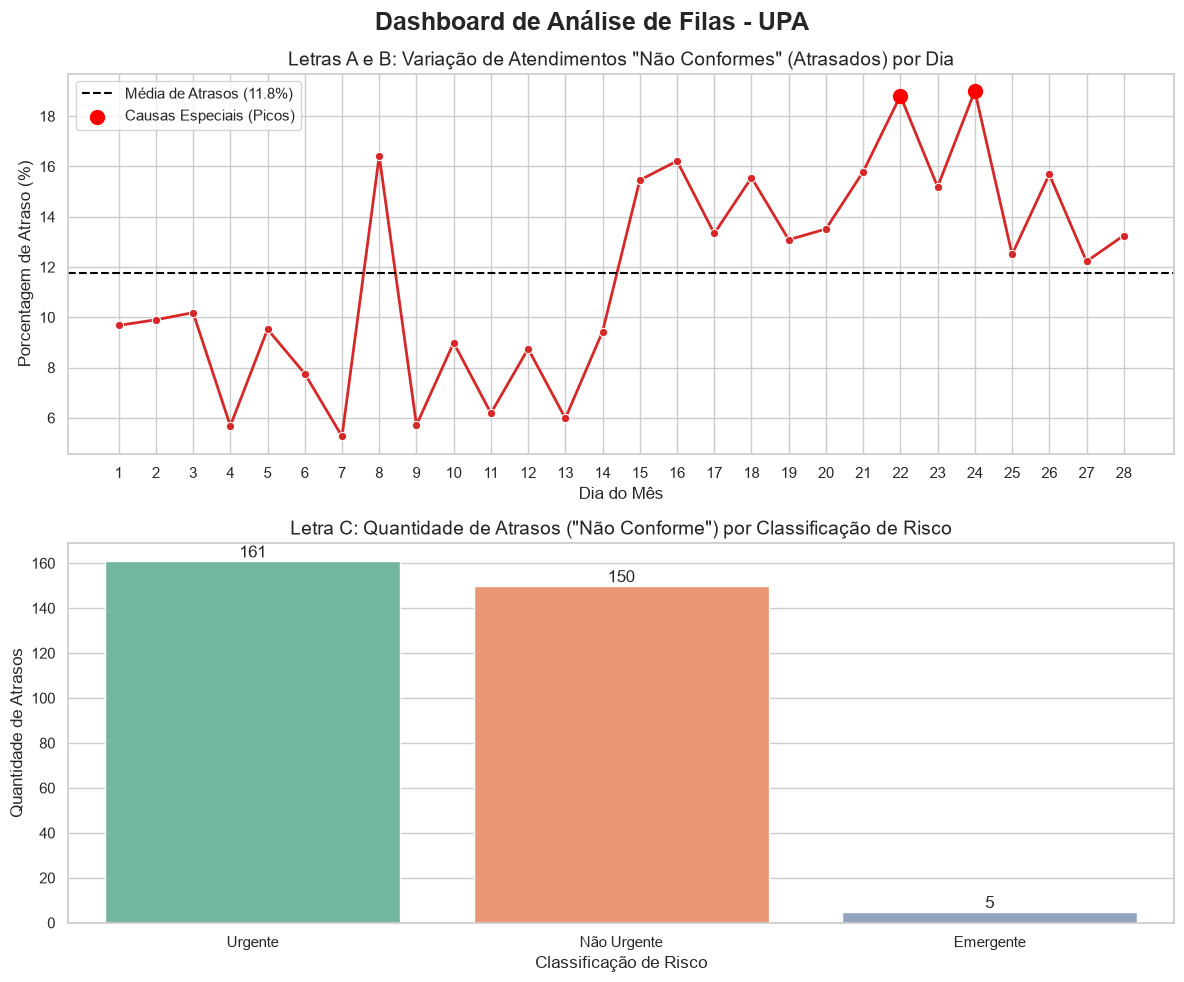

In [ ]:
print("Gerando o Dashboard de Análise de Fila... (Feche a janela para encerrar)")

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
fig.suptitle('Dashboard de Análise de Filas - UPA', fontsize=18, fontweight='bold')

# --- Letra A e B: Tendência de Atrasos por Dia ---
sns.lineplot(data=desempenho_dia, x='Dia', y='%_Atraso', marker='o', color='#d62828', linewidth=2, ax=axes[0])
axes[0].axhline(media_atraso_geral, color='black', linestyle='--', label=f'Média de Atrasos ({media_atraso_geral:.1f}%)')

# Destacando picos (Causas Especiais) - Dias onde o atraso passou muito da média
picos = desempenho_dia[desempenho_dia['%_Atraso'] > media_atraso_geral * 1.5]
if not picos.empty:
    axes[0].scatter(picos['Dia'], picos['%_Atraso'], color='red', s=100, zorder=5, label='Causas Especiais (Picos)')

axes[0].set_title('Letras A e B: Variação de Atendimentos "Não Conformes" (Atrasados) por Dia', fontsize=14)
axes[0].set_ylabel('Porcentagem de Atraso (%)')
axes[0].set_xlabel('Dia do Mês')
axes[0].set_xticks(desempenho_dia['Dia']) # Força aparecer todos os números dos dias
axes[0].legend()

# --- Letra C: Atrasos por Classificação de Risco ---
# Aqui fazemos um countplot (gráfico de barras de contagem) filtrando apenas a base 'atrasos'
ordem_risco = atrasos['Classificação de Risco'].value_counts().index # Ordena da maior causa para a menor
sns.countplot(data=atrasos, x='Classificação de Risco', order=ordem_risco, palette='Set2', ax=axes[1])

axes[1].set_title('Letra C: Quantidade de Atrasos ("Não Conforme") por Classificação de Risco', fontsize=14)
axes[1].set_ylabel('Quantidade de Atrasos')
axes[1].set_xlabel('Classificação de Risco')
for container in axes[1].containers:
    axes[1].bar_label(container) # Loop para colocar os valores em cima das barras

plt.tight_layout()
plt.show()